In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
data_path = 'data/'
df_lists = []

customers_df = pd.read_csv(data_path + 'olist_customers_dataset.csv')
geolocation_df = pd.read_csv(data_path + 'olist_geolocation_dataset.csv')
order_items_df = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
order_payments_df = pd.read_csv(data_path + 'olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')
orders_df = pd.read_csv(data_path + 'olist_orders_dataset.csv')
products_df = pd.read_csv(data_path + 'olist_products_dataset.csv')
sellers_df = pd.read_csv(data_path + 'olist_sellers_dataset.csv')
category_translation_df = pd.read_csv(data_path + 'product_category_name_translation.csv')

df_lists.append(customers_df)
df_lists.append(geolocation_df)
df_lists.append(order_items_df)
df_lists.append(order_payments_df)
df_lists.append(order_reviews_df)
df_lists.append(orders_df)
df_lists.append(products_df)
df_lists.append(sellers_df)
df_lists.append(category_translation_df)

df_names = ['customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'products', 'sellers', 'category_translation']

In [ ]:
def exploratory_analysis(df, df_name):
    print(f"\n=== Análisis Exploratorio para {df_name} ===\n")
    
    print("1. Información general:")
    print(df.info())
    print("\nPrimeras 5 filas:")
    print(df.head())
    
    print("\n2. Valores nulos:")
    null_counts = df.isnull().sum()
    null_percentage = (null_counts / len(df)) * 100
    null_summary = pd.DataFrame({'Nulos': null_counts, 'Porcentaje': null_percentage})
    print(null_summary[null_summary['Nulos'] > 0])
    
    print("\n3. Estadísticas descriptivas (numéricas):")
    print(df.describe())
    
    print("\nEstadísticas descriptivas (categóricas):")
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        print(f"\nColumna: {col}")
        print(df[col].value_counts().head())
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 1:
        print("\n4. Matriz de correlación:")
        corr_matrix = df[numeric_cols].corr()
        print(corr_matrix)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title(f'Matriz de Correlación - {df_name}')
        plt.show()
    
    # 5. Visualizaciones
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Histograma de {col} - {df_name}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.show()
        
    # Boxplots para columnas numéricas
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Boxplot de {col} - {df_name}')
        plt.xlabel(col)
        plt.show()


=== Análisis Exploratorio para customers ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Primeras 5 filas:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4

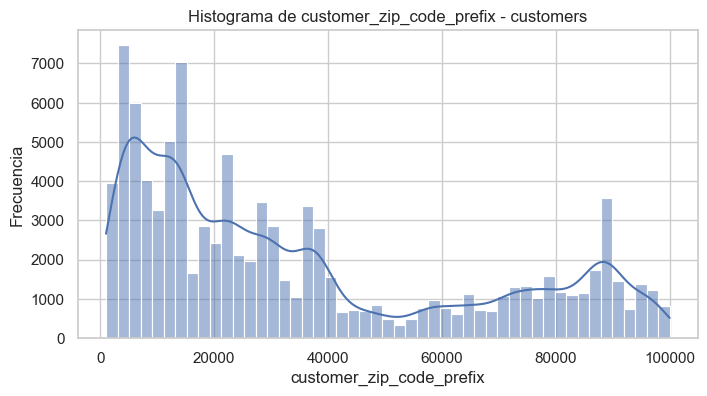

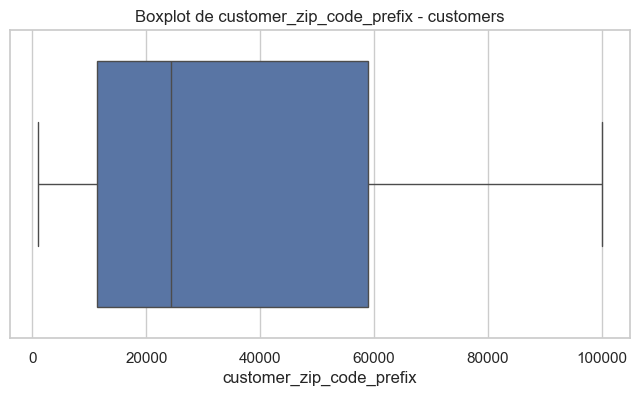


=== Análisis Exploratorio para geolocation ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB
None

Primeras 5 filas:
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041      

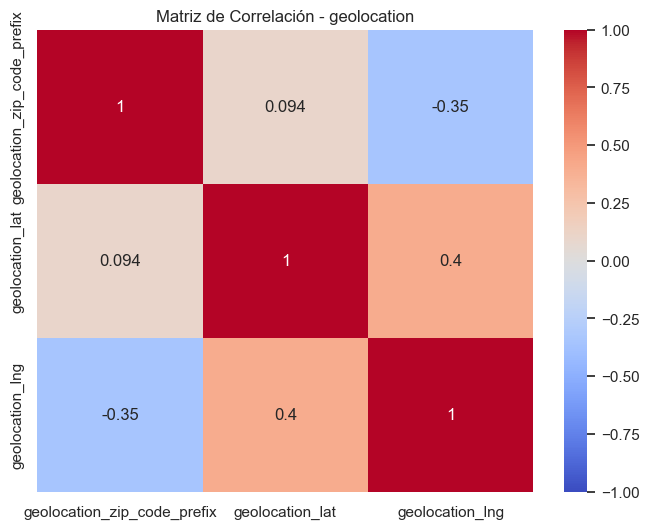

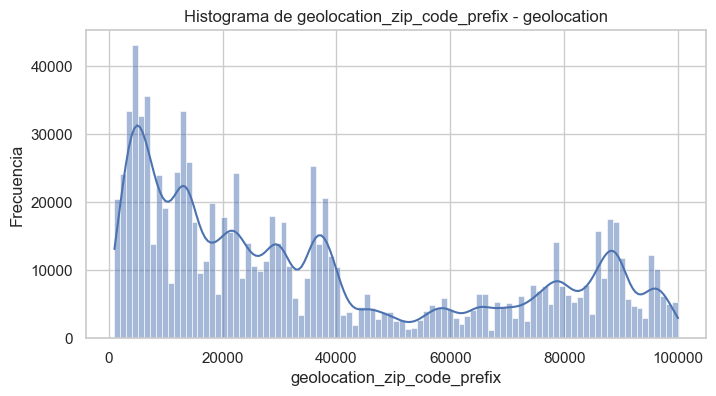

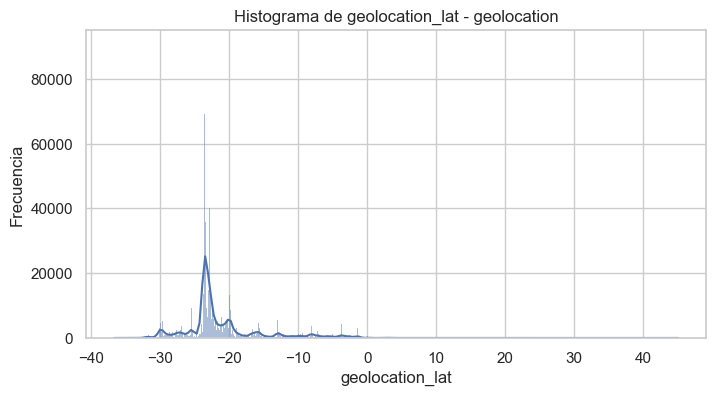

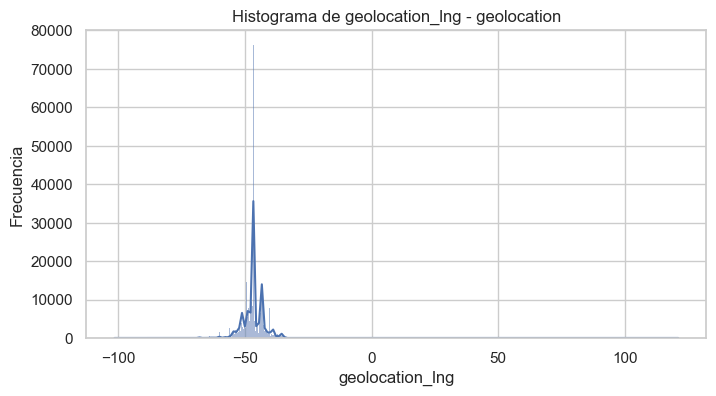

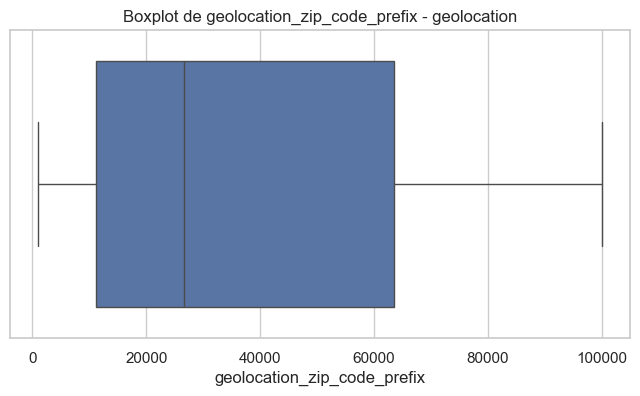

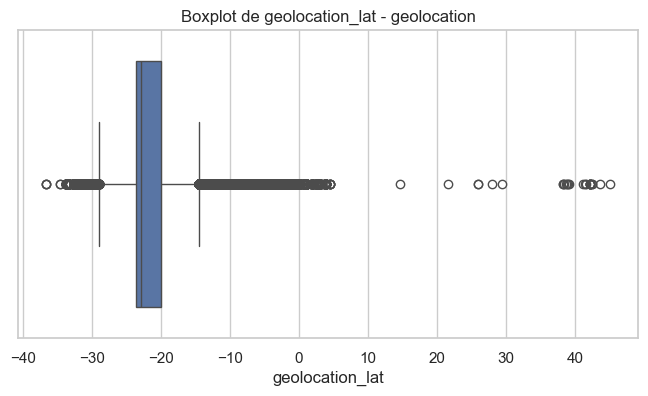

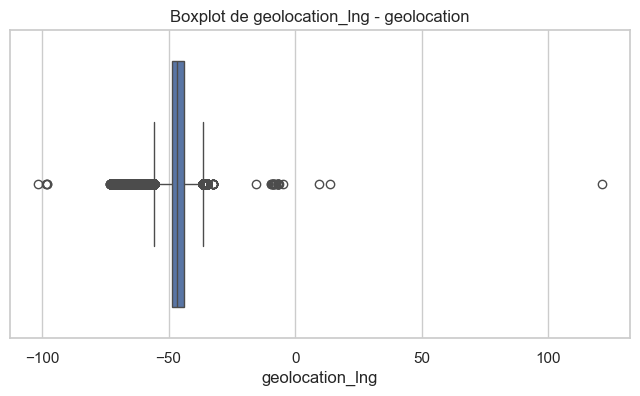


=== Análisis Exploratorio para order_items ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Primeras 5 filas:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4 

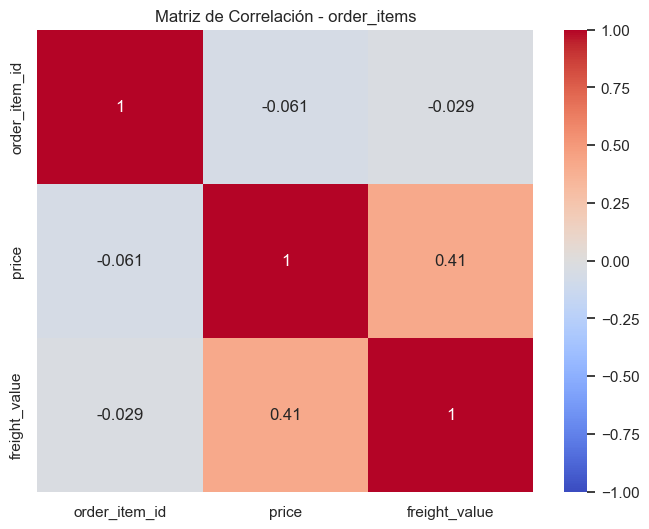

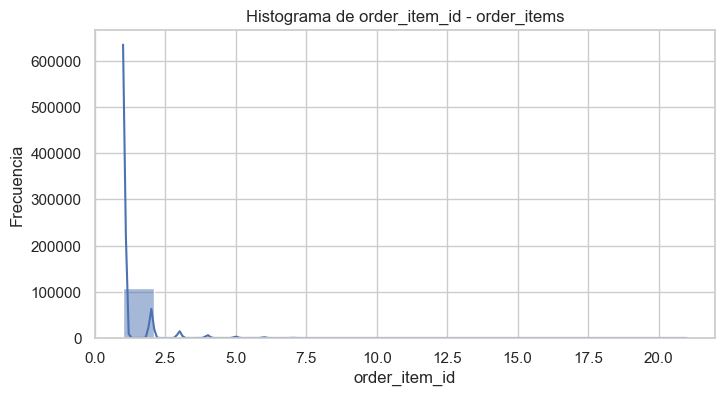

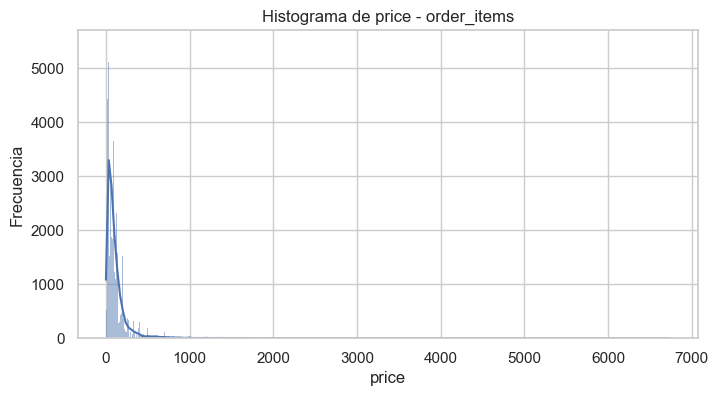

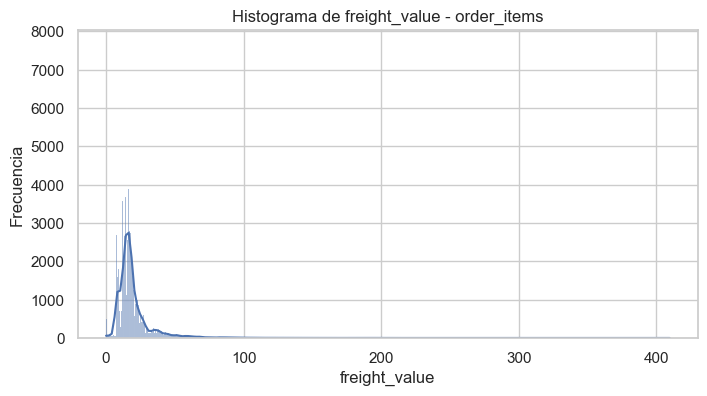

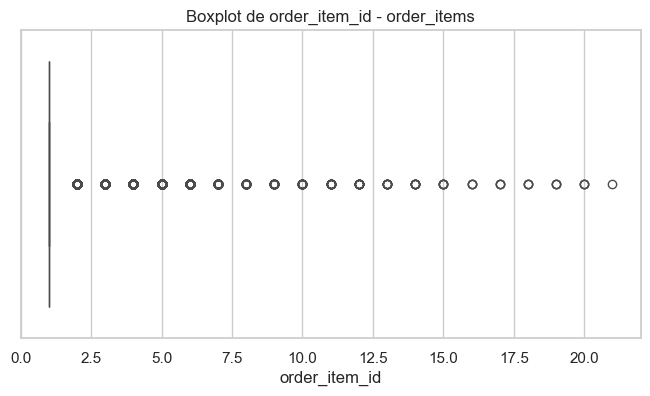

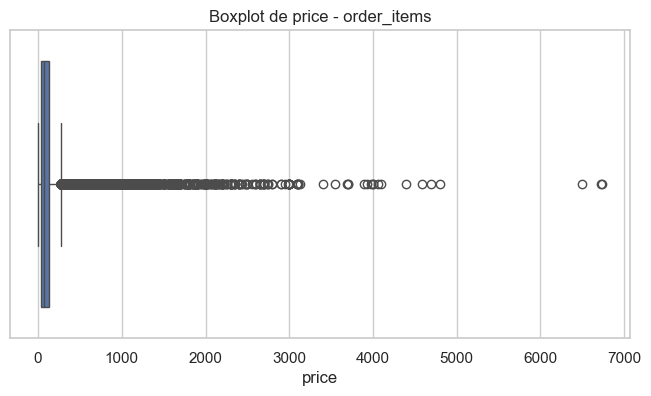

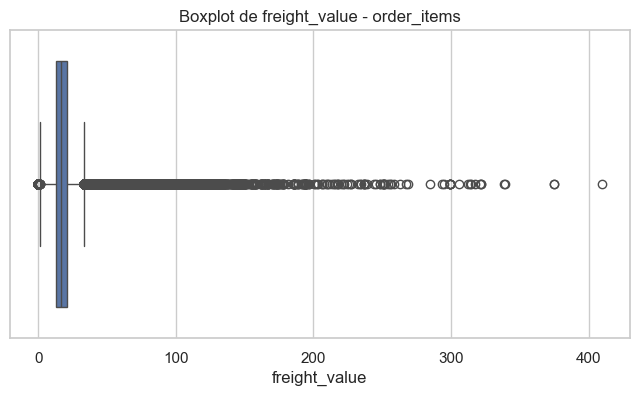


=== Análisis Exploratorio para order_payments ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
None

Primeras 5 filas:
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  4

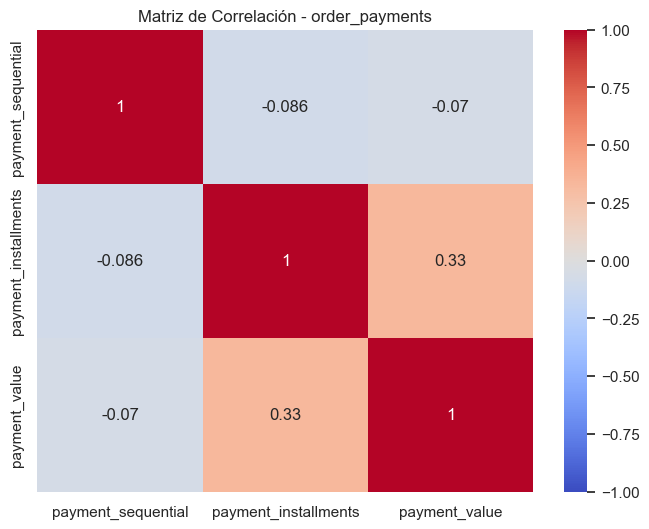

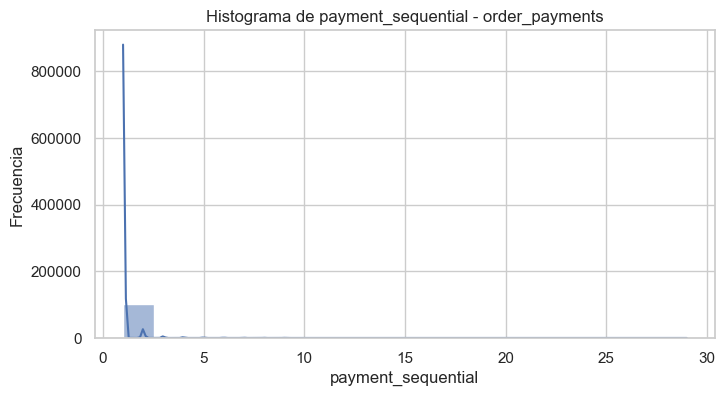

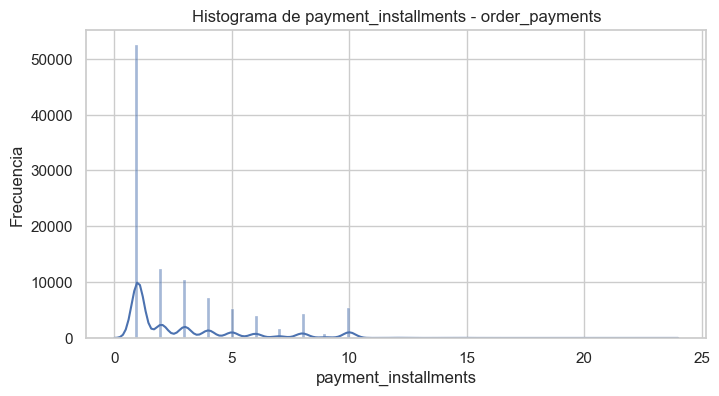

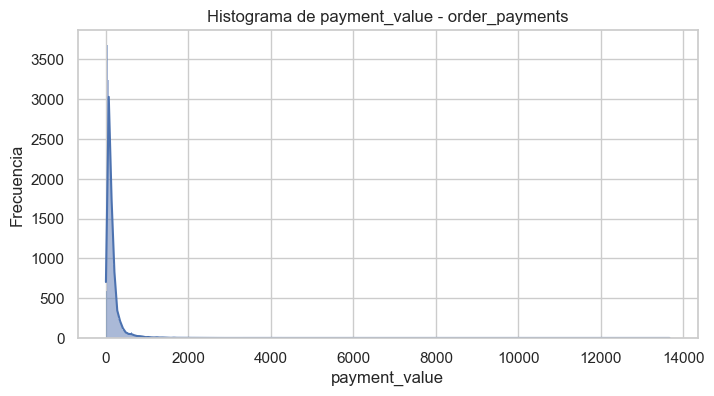

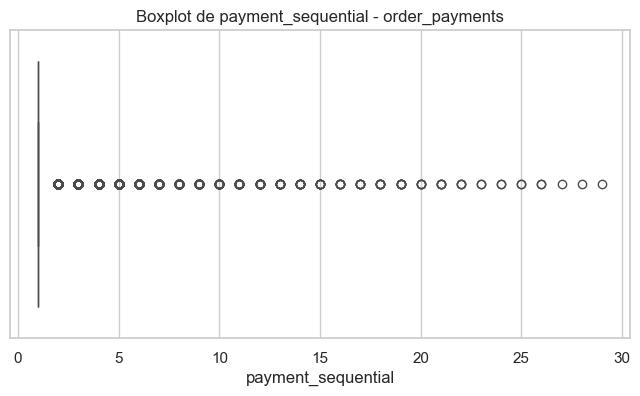

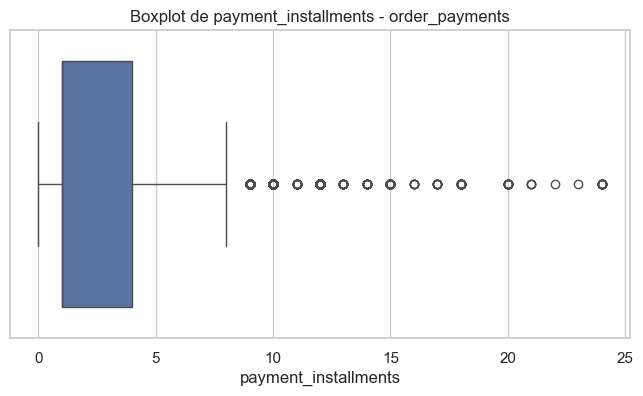

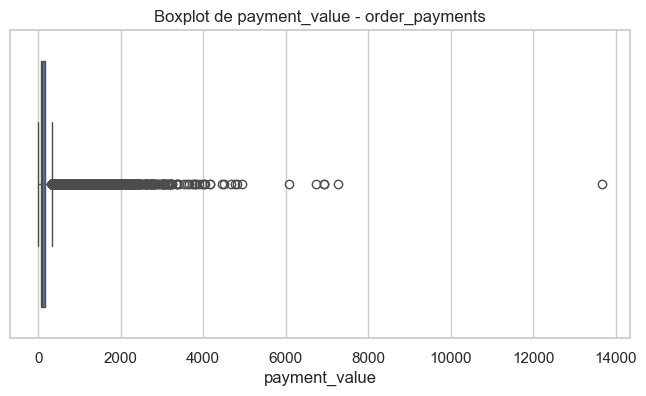


=== Análisis Exploratorio para order_reviews ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Primeras 5 filas:
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b2

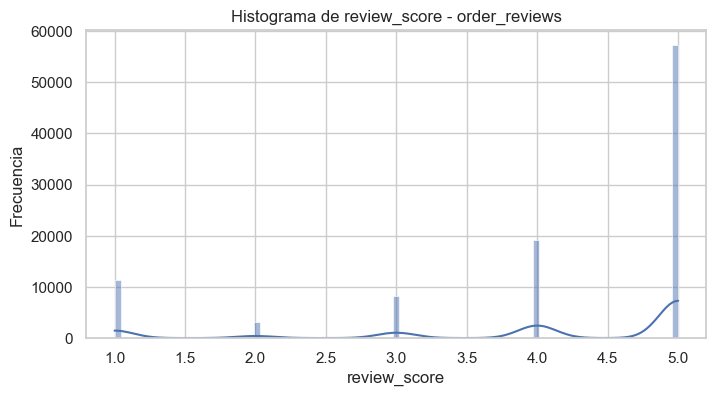

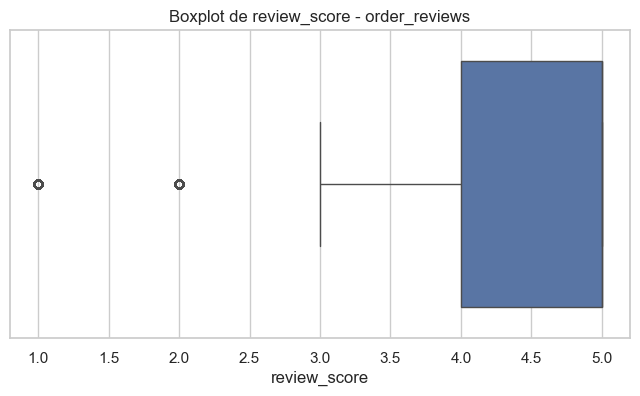


=== Análisis Exploratorio para orders ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Primeras 5 filas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741

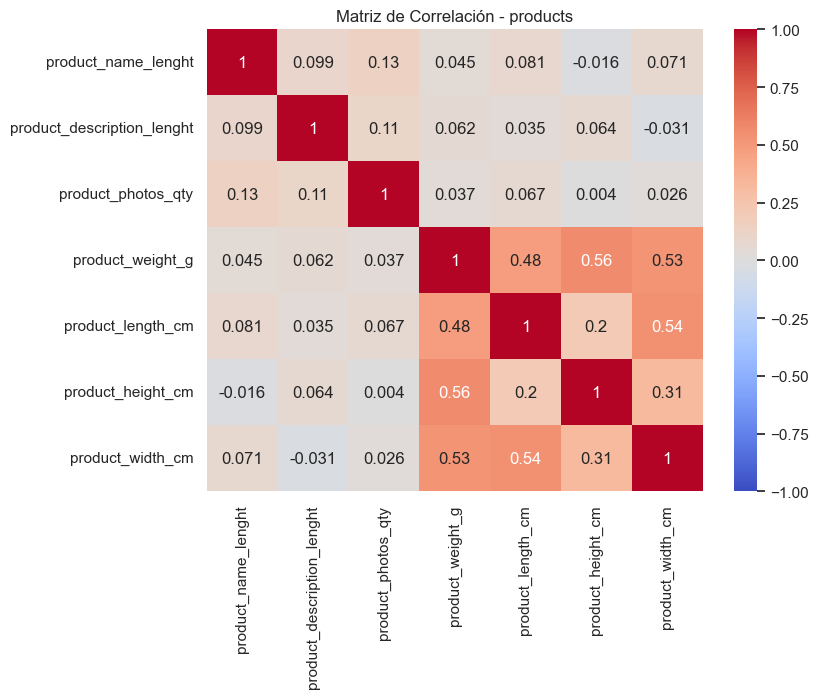

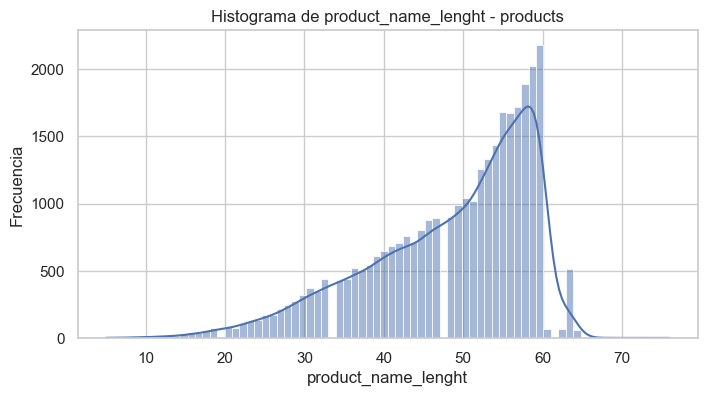

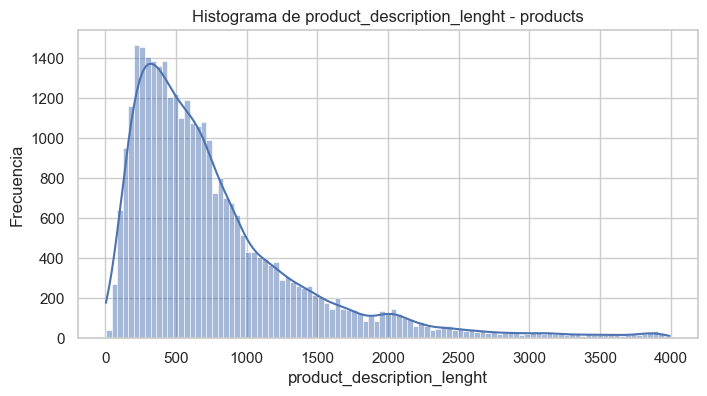

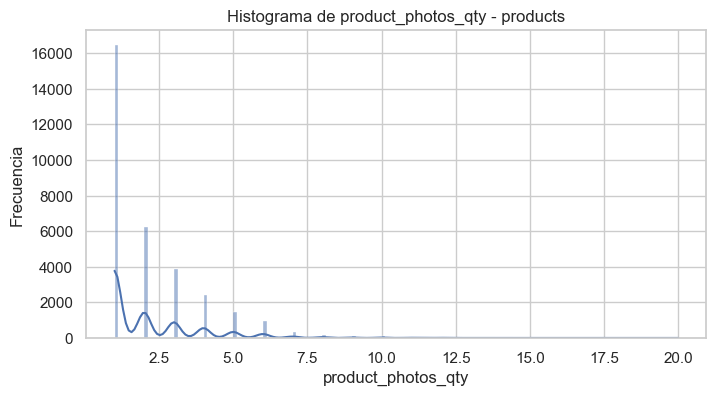

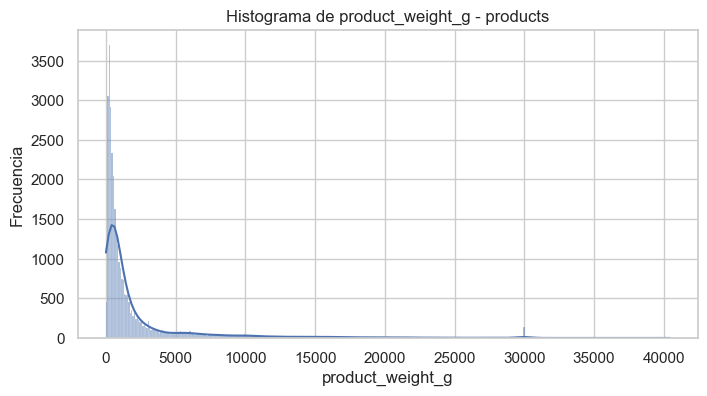

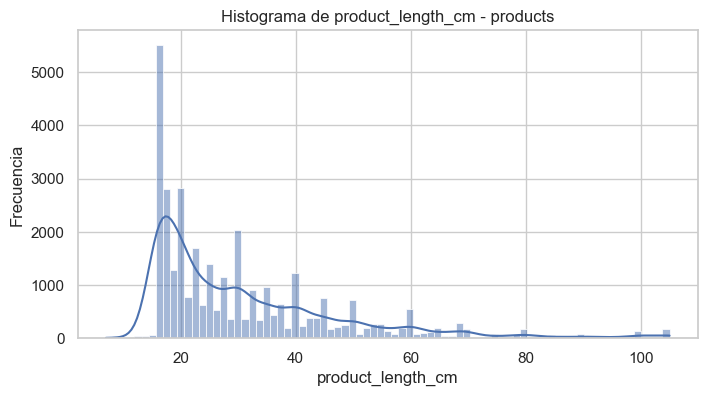

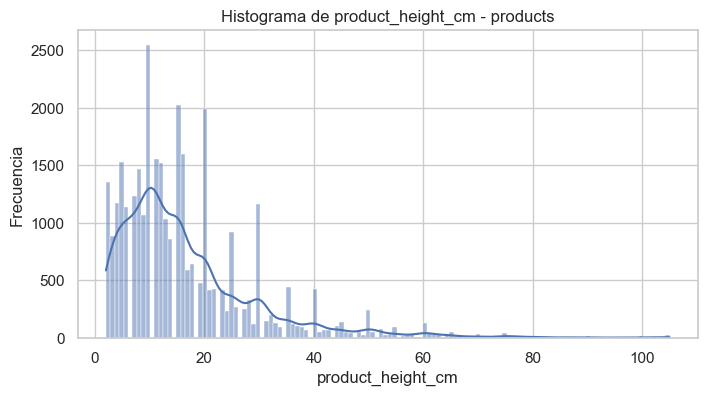

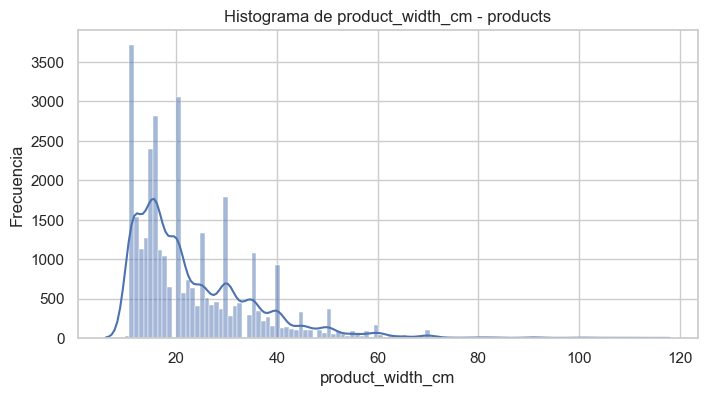

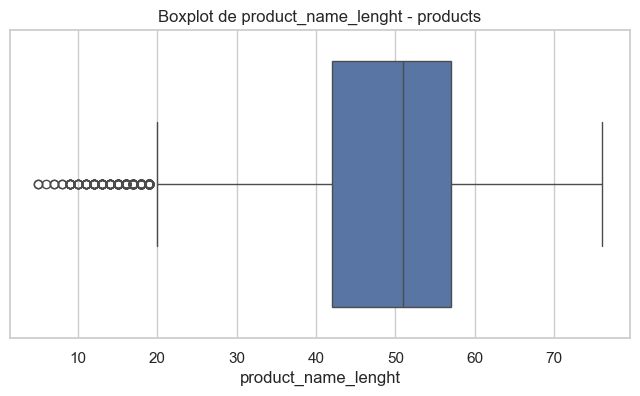

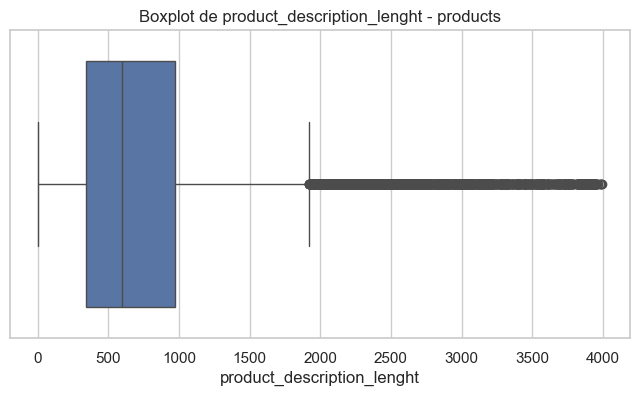

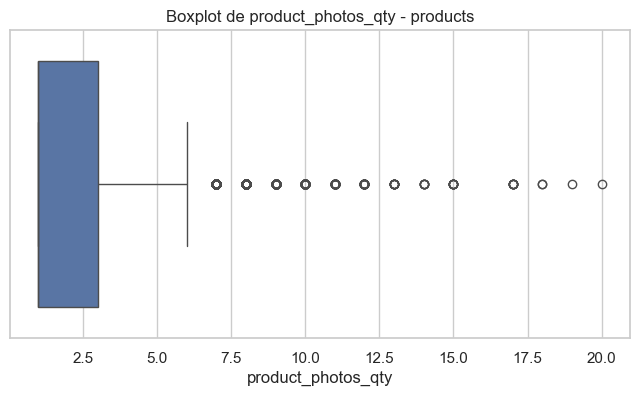

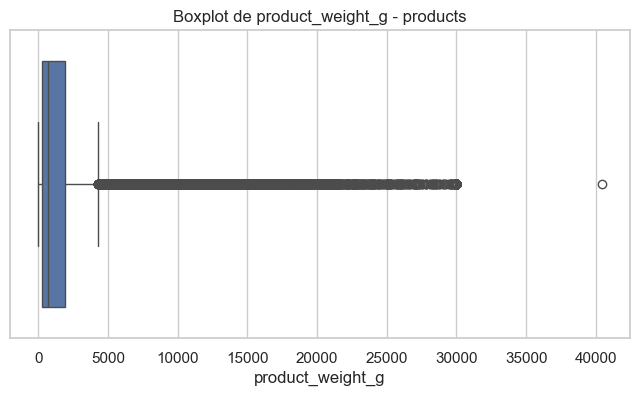

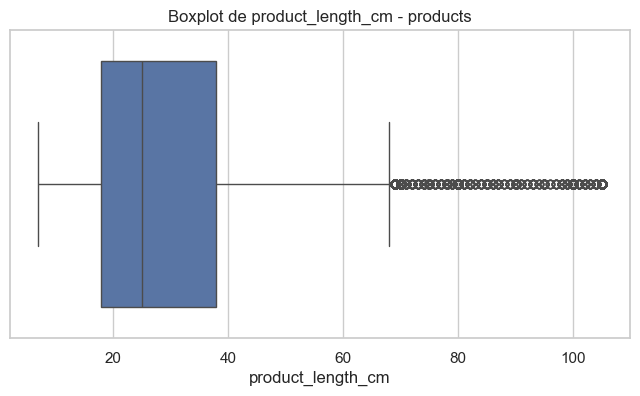

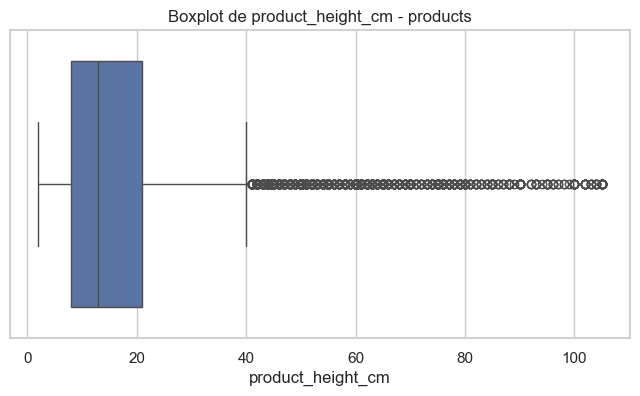

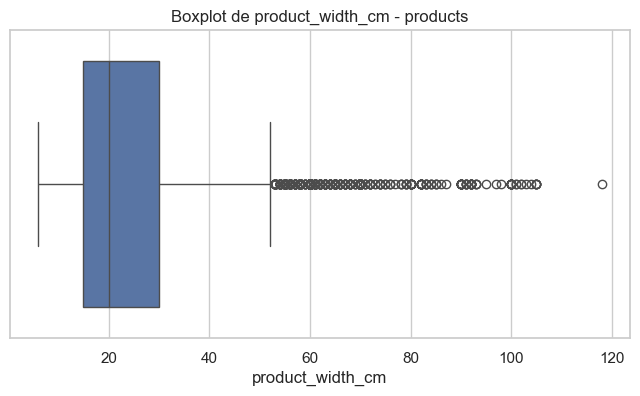


=== Análisis Exploratorio para sellers ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
None

Primeras 5 filas:
                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas   

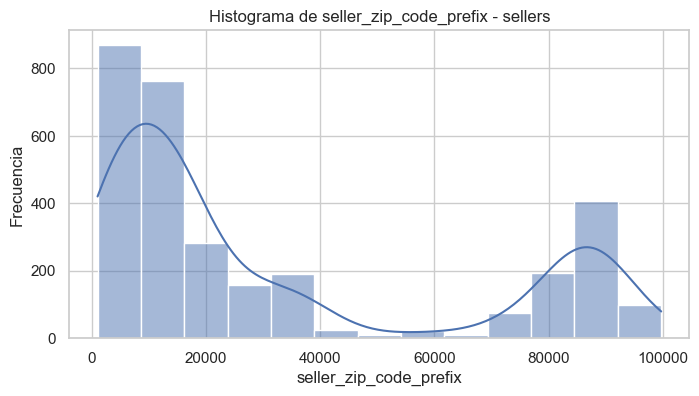

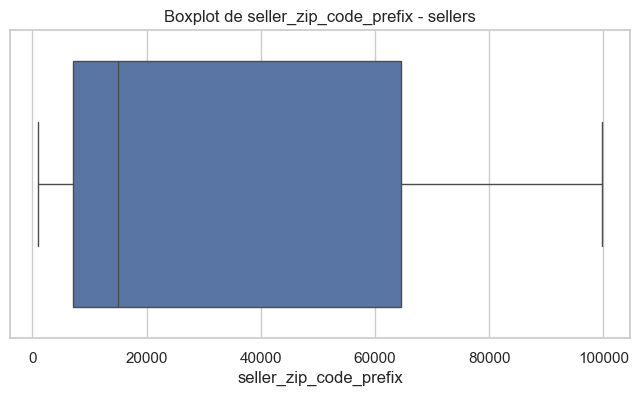


=== Análisis Exploratorio para category_translation ===

1. Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None

Primeras 5 filas:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor

2. Valores nulos:
Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []

3. Estadísticas descriptivas (numéricas):
       product_category_name product_category_name_english
coun

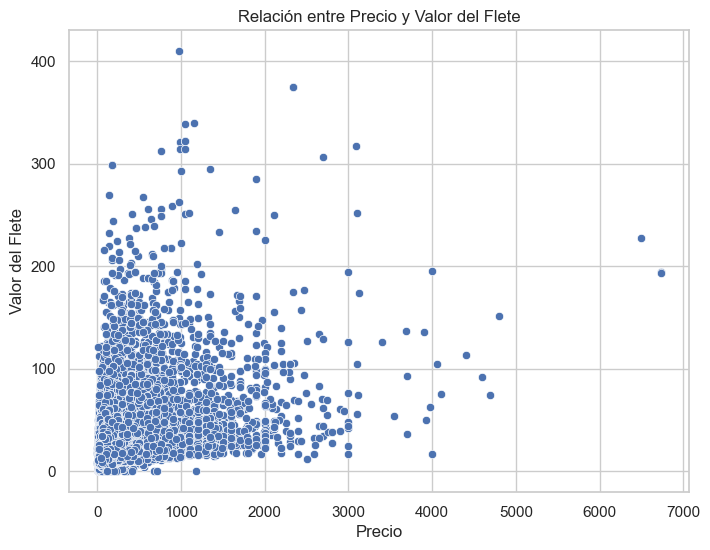

In [ ]:

for df, name in zip(df_lists, df_names):
    exploratory_analysis(df, name)

print("\n=== Análisis adicional: Relaciones entre DataFrames ===")
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='inner')
print("\nEjemplo de fusión: orders y order_items")
print(merged_df.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=order_items_df, x='price', y='freight_value')
plt.title('Relación entre Precio y Valor del Flete')
plt.xlabel('Precio')
plt.ylabel('Valor del Flete')
plt.show()

In [16]:
for df, name in zip(df_lists, df_names):
    print("\nValores nulos en el DataFrame: ", name)
    null_counts = df.isnull().sum()
    null_percentage = (null_counts / len(df)) * 100
    null_summary = pd.DataFrame({'Nulos': null_counts, 'Porcentaje': null_percentage})
    print(null_summary[null_summary['Nulos'] > 0])


Valores nulos en el DataFrame:  customers
Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []

Valores nulos en el DataFrame:  geolocation
Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []

Valores nulos en el DataFrame:  order_items
Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []

Valores nulos en el DataFrame:  order_payments
Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []

Valores nulos en el DataFrame:  order_reviews
                        Nulos  Porcentaje
review_comment_title    87656   88.341530
review_comment_message  58247   58.702532

Valores nulos en el DataFrame:  orders
                               Nulos  Porcentaje
order_approved_at                160    0.160899
order_delivered_carrier_date    1783    1.793023
order_delivered_customer_date   2965    2.981668

Valores nulos en el DataFrame:  products
                            Nulos  Porcentaje
product_category_name         610    1.851234
product_name_lenght           610    1.851234
product_de